In [27]:
import sys, os, json, pickle, random, heapq
from PIL import Image
import matplotlib.pyplot as plt
import torch
import numpy as np

# add project root so “utils.” and “models.” imports work
sys.path.append(os.path.abspath(".."))

from models.model import CaptionGenerator
from utils.vocab import Vocabulary


In [28]:
# ---------- vocabulary ----------
with open("../data/vocab.pkl", "rb") as f:
    vocab: Vocabulary = pickle.load(f)

# ---------- model ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
embed_size, hidden_size, num_layers = 256, 512, 1
model = CaptionGenerator(embed_size, hidden_size, len(vocab), num_layers).to(device)
model.load_state_dict(torch.load("../outputs/caption_model.pth", map_location=device))
model.eval()

print(f"✅ model & vocab loaded on {device}")


✅ model & vocab loaded on cpu


In [29]:
with open("../data/image_features.json", "r") as f:
    image_features = json.load(f)

IMG_FOLDER = "../data/flickr8k_dataset"


In [43]:
# ── GREEDY DECODER ───────────────────────────────────────────────────
def generate_caption_greedy(model, feat_vec, vocab, max_len=20):
    feat = torch.tensor(feat_vec, dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        h = torch.tanh(model.init_hidden(feat)).unsqueeze(0)
        c = torch.zeros_like(h)

        tokens = [vocab.stoi["<SOS>"]]
        out_words = []

        for _ in range(max_len):
            inp = torch.tensor([[tokens[-1]]], dtype=torch.long).to(device)
            emb = model.embed(inp)
            out, (h, c) = model.lstm(emb, (h, c))
            next_tok = model.linear(out.squeeze(1)).argmax(1).item()
            if next_tok == vocab.stoi["<EOS>"]:
                break
            out_words.append(vocab.itos.get(next_tok, "<UNK>"))
            tokens.append(next_tok)
    return " ".join(out_words)

# ── BEAM-SEARCH DECODER ──────────────────────────────────────────────
def generate_caption_beam(model, feat_vec, vocab, beam=3, max_len=20):
    fv = torch.tensor(feat_vec, dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        h = torch.tanh(model.init_hidden(fv)).unsqueeze(0)
        c = torch.zeros_like(h)
        beam_seq = [(0.0, [vocab.stoi["<SOS>"]], h, c)]   # (score, seq, h, c)

        for _ in range(max_len):
            new_beam = []
            for score, seq, h, c in beam_seq:
                inp = torch.tensor([[seq[-1]]], dtype=torch.long).to(device)
                emb = model.embed(inp)
                out, (h2, c2) = model.lstm(emb, (h, c))
                log_p = torch.log_softmax(model.linear(out.squeeze(1)), dim=1)
                top_p, top_ix = torch.topk(log_p, beam)

                for i in range(beam):
                    tok  = top_ix[0, i].item()
                    sc   = score + top_p[0, i].item()
                    new_beam.append((sc, seq + [tok], h2, c2))

            beam_seq = heapq.nlargest(beam, new_beam, key=lambda x: x[0])
            if all(seq[-1] == vocab.stoi["<EOS>"] for _, seq, _, _ in beam_seq):
                break

        best = beam_seq[0][1]
        words = [vocab.itos[idx] for idx in best[1:] if idx != vocab.stoi["<EOS>"]]
        return " ".join(words)

# ── RANDOM-IMAGE DISPLAY UTIL ────────────────────────────────────────
def caption_random_image_beam(model, features, vocab, img_folder,
                              beam_width=5, max_len=20):
    img_name      = random.choice(list(features.keys()))
    caption       = generate_caption_beam(model, features[img_name],
                                          vocab, beam_width, max_len)

    img_path = f"{img_folder}/{img_name}"
    img = Image.open(img_path)

    plt.imshow(img)
    plt.title(caption)
    plt.axis("off")
    plt.show()

    print(f"🖼️  {img_name}")
    print(f"📝  {caption}")


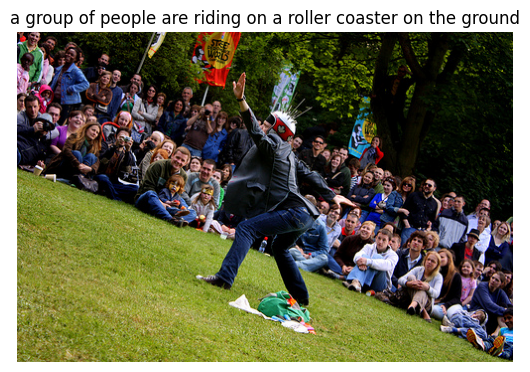

🖼️  3677302645_8cd3fac70d.jpg
📝  a group of people are riding on a roller coaster on the ground


In [44]:
caption_random_image_beam(
    model=model,
    features=image_features,
    vocab=vocab,
    img_folder=IMG_FOLDER,
    beam_width=5
)


📜 5 reference captions for this image ⤵︎
  • a group of women are standing in front of a building
  • a woman in a white gown stands with other girls dressed up one points across the street
  • five women in dresses one holding a child stand outside
  • four women and a bride stand on a street while one of them points at something in the distance
  • old lady with black dress and hat points out something to bride

🤖 Greedy : a woman in a white shirt and a man in a black shirt and a woman in a black shirt
🤖 Beam-5 : a group of people are standing in front of a christmas tree <UNK>


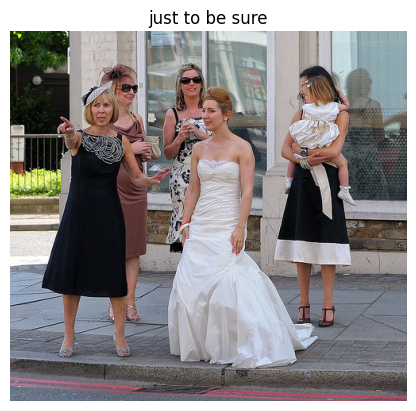

In [45]:
# --- 1. pick the SAME img you just visualised ------------
img_name = "3614542901_29877fc342.jpg"      # paste from output

# --- 2. show the five ground-truth captions --------------
with open("../data/cleaned_captions.json") as f:
    caps = json.load(f)[img_name]
print("📜 5 reference captions for this image ⤵︎")
for c in caps:
    print("  •", c)

# --- 3. regenerate via greedy & wider beam ---------------
feature_vec = features[img_name]
print("\n🤖 Greedy :", generate_caption_greedy(model, feature_vec, vocab))
print("🤖 Beam-5 :", generate_caption_beam(model, feature_vec, vocab,
                                           beam=5))

# --- 4. show the photo again -----------------------------
plt.imshow(Image.open(f"../data/flickr8k_dataset/{img_name}"))
plt.title("just to be sure")
plt.axis("off")
plt.show()
